In [1]:
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import gsw
import cartopy.crs as ccrs
import earthaccess
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import h5py

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
import numpy as np
import xarray as xr
from oneargopy.OneArgo import Argo
from argopy import DataFetcher as ArgoDataFetcher
import pandas as pd
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
import cmocean
import matplotlib.colors as mcolors
import matplotlib.dates as mdates
import matplotlib.cm as cm # new package for the colorbar
import matplotlib.patches as mpatches
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter
from matplotlib.ticker import LogLocator, FormatStrFormatter
from matplotlib.colors import LogNorm
import matplotlib.path as mpath
import xarray.ufuncs as xu
import gsw

## Earthaccess login

In [2]:
auth = earthaccess.login(persist=True)

## Searching for data

In [3]:
results = earthaccess.search_datasets(instrument="MODIS")

In [4]:
for item in results:
    summary = item.summary()
    print(summary["short-name"])

CIESIN_SEDAC_USPAT_USUEXT2015
Sat_ActiveLayer_Thickness_Maps_1760
ABoVE_MODIS_MAIAC_Reflectance_1858
Wildfires_NWT_Canada_1548
Wildfires_2014_NWT_Canada_1307
Burned_Area_Depth_AK_CA_2063
MODIS_MAIAC_Reflectance_1700
Dall_Sheep_Population_Dynamics_1640
Dall_Sheep_Snowpack_1602
Effect_Environment_Moose_1739
ABoVE_Frac_Open_Water_1362
Snow_Cover_Extent_and_Depth_1757
BurnedArea_Emissions_AK_YT_NWT_1812
Last_Day_Spring_Snow_1528
GPP_MODIS_Alaska_Canada_2024
MODIS_CCaN_NDVI_Trends_Alaska_1666
Albedo_Boreal_North_America_1605
Alaska_Yukon_NDVI_1614
NorthSlope_NEE_TVPRM_1920
Wildfires_Date_of_Burning_1559
Wolves_Denning_Pups_Climate_1846
AGB_Pantropics_Amazon_Mexico_1824
ACTIVATE-MODIS-MERRA2
ADAM.Surface.Reflectance.Database
CIESIN_AfSIS_MODIS_ALB2012
CIESIN_AfSIS_MODIS_LCT2012
CIESIN_AfSIS_MODIS_LST201404
CIESIN_AfSIS_MODIS_LAIFPAR2012
CIESIN_AfSIS_MODIS_PP2012
CIESIN_AfSIS_MODIS_VEGIN201404
aad_ais_gz_modis_slope_break
AMDBLWV
AMDBLWV
AMMBLWV
AMMBLWV
NSIDC-0432
UNIZH_AGREG
CIESIN_SEDAC_SDE

/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11069/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11069/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11069/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  summary = item.summary()
/var/folders/sr/nn_fjjln6s33md98tyfc3rd40000gn/T/ipykernel_11069/2661939172.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `Da

In [5]:
results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    count=1,
)
len(results)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


1

## Refining search using time, space, cloud cover etc

In [22]:
tspan = ("2026-01-01", "2026-01-31")
bbox = (150, -78, 160, -70)
# bbox = (155, -65, 160, -60) # west, south, east, north 
clouds = (0, 100)
# cloud_cover=clouds

In [23]:
results = earthaccess.search_data(
    short_name="MODISA_L3m_CHL",
    temporal=tspan,
    bounding_box=bbox)
len(results)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/results.py:348: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  self["size"] = self.size()


100

## Opening files without downloading them (streaming them)

In [24]:
paths = earthaccess.open(results)

/opt/anaconda3/envs/IBIS_Project/lib/python3.13/site-packages/earthaccess/store.py:523: FutureWarning: As of version 1.0, `DataGranule.size` will be accessed as an attribute; e.g. use `DataCollection.size` **not** `DataCollection.size()`
  total_size = round(sum([granule.size() for granule in granules]) / 1024, 2)
QUEUEING TASKS | : 100%|██████████| 100/100 [00:00<00:00, 16236.22it/s]
PROCESSING TASKS | : 100%|██████████| 100/100 [00:14<00:00,  6.90it/s]
COLLECTING RESULTS | : 100%|██████████| 100/100 [00:00<00:00, 320420.47it/s]


In [25]:
paths

[<File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20021221_20260320.L3m.SCWI.CHL.chlor_a.9km.nc>,
 <File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20021221_20260320.L3m.SCWI.CHL.chlor_a.4km.nc>,
 <File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20030101_20260131.L3m.MC.CHL.chlor_a.9km.nc>,
 <File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20030101_20260131.L3m.MC.CHL.chlor_a.4km.nc>,
 <File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20030201_20260228.L3m.MC.CHL.chlor_a.9km.nc>,
 <File-like object HTTPFileSystem, https://obdaac-tea.earthdatacloud.nasa.gov/ob-cumulus-prod-public/AQUA_MODIS.20030201_20260228.L3m.MC.CHL.chlor_a.4km.nc>,
 <File-like object HTTPFileSystem, https://obdaa

## Opening files into xarrays and merging variables into one

In [26]:
dataset = xr.open_dataset(paths[0])
dataset

<xarray.Dataset> Size: 37MB
Dimensions:  (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 37MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      AQUA_MODIS.20021221_20260320.L3m.SCWI....
    instrument:                        MODIS
    title:                             MODISA Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Aqua
    source:                            satellite observations from MODIS-Aqua
    ...                                ...
    identifier_product_doi:            10.5067/AQUA/MODIS/L3M/CHL/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         5272661
    data_minimum:                      0.0016383681
    data_maximum:                      86.2311

In [27]:
datatree = xr.open_datatree(paths[0])
datatree

<xarray.DataTree>
Group: /
│   Dimensions:  (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
│   Coordinates:
│     * lat      (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
│     * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
│   Dimensions without coordinates: rgb, eightbitcolor
│   Data variables:
│       chlor_a  (lat, lon) float32 37MB ...
│       palette  (rgb, eightbitcolor) uint8 768B ...
│   Attributes: (12/64)
│       product_name:                      AQUA_MODIS.20021221_20260320.L3m.SCWI....
│       instrument:                        MODIS
│       title:                             MODISA Level-3 Standard Mapped Image
│       project:                           Ocean Biology Processing Group (NASA/G...
│       platform:                          Aqua
│       source:                            satellite observations from MODIS-Aqua
│       ...                                ...
│       identifier_product_doi:            10.5067/AQUA/MODIS/L3M/CHL/2022
│       keywords:                          Earth Science > Oceans > Ocean Chemist...
│       keywords_vocabulary:               NASA Global Change Master Directory (G...
│       data_bins:                         5272661
│       data_minimum:                      0.0016383681
│       data_maximum:                      86.2311
└── Group: /processing_control
    │   Attributes:
    │       software_name:     l3mapgen
    │       software_version:  3.2.0-V2026.3
    │       input_sources:     AQUA_MODIS.20021221_20260320.L3b.SCWI.CHL.nc
    │       l2_flag_names:     ATMFAIL,LAND,HILT,HISATZEN,STRAYLIGHT,CLDICE,COCCOLITH...
    └── Group: /processing_control/input_parameters
            Attributes: (12/48)
                par:                AQUA_MODIS.20021221_20260320.L3m.SCWI.CHL.chlor_a.9km...
                suite:              CHL
                ifile:              AQUA_MODIS.20021221_20260320.L3b.SCWI.CHL.nc
                ofile:              AQUA_MODIS.20021221_20260320.L3m.SCWI.CHL.chlor_a.9km.nc
                oformat:            2
                ofile_product_tag:  PRODUCT
                ...                 ...
                num_cache:          500
                mask_land:          no
                rgb_land:           160,82,45
                land:               $OCDATAROOT/common/landmask_GMT15ARC.nc
                full_latlon:        yes
                doi:                10.5067/AQUA/MODIS/L3M/CHL/2022

In [28]:
dataset = xr.merge(datatree.to_dict().values())
dataset

<xarray.Dataset> Size: 37MB
Dimensions:  (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 37MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      AQUA_MODIS.20021221_20260320.L3m.SCWI....
    instrument:                        MODIS
    title:                             MODISA Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Aqua
    source:                            satellite observations from MODIS-Aqua
    ...                                ...
    identifier_product_doi:            10.5067/AQUA/MODIS/L3M/CHL/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         5272661
    data_minimum:                      0.0016383681
    data_maximum:                      86.2311

In [29]:
dataset["lat"] = dataset["lat"].clip(
    min=dataset["lat"].attrs["valid_min"],
    max=dataset["lat"].attrs["valid_max"]
)

dataset["lon"] = dataset["lon"].clip(
    min=dataset["lon"].attrs["valid_min"],
    max=dataset["lon"].attrs["valid_max"]
)

In [30]:
dataset

<xarray.Dataset> Size: 37MB
Dimensions:  (lat: 2160, lon: 4320, rgb: 3, eightbitcolor: 256)
Coordinates:
  * lat      (lat) float32 9kB 89.96 89.88 89.79 89.71 ... -89.79 -89.88 -89.96
  * lon      (lon) float32 17kB -180.0 -179.9 -179.8 ... 179.8 179.9 180.0
Dimensions without coordinates: rgb, eightbitcolor
Data variables:
    chlor_a  (lat, lon) float32 37MB ...
    palette  (rgb, eightbitcolor) uint8 768B ...
Attributes: (12/64)
    product_name:                      AQUA_MODIS.20021221_20260320.L3m.SCWI....
    instrument:                        MODIS
    title:                             MODISA Level-3 Standard Mapped Image
    project:                           Ocean Biology Processing Group (NASA/G...
    platform:                          Aqua
    source:                            satellite observations from MODIS-Aqua
    ...                                ...
    identifier_product_doi:            10.5067/AQUA/MODIS/L3M/CHL/2022
    keywords:                          Earth Science > Oceans > Ocean Chemist...
    keywords_vocabulary:               NASA Global Change Master Directory (G...
    data_bins:                         5272661
    data_minimum:                      0.0016383681
    data_maximum:                      86.2311

## Testing variables

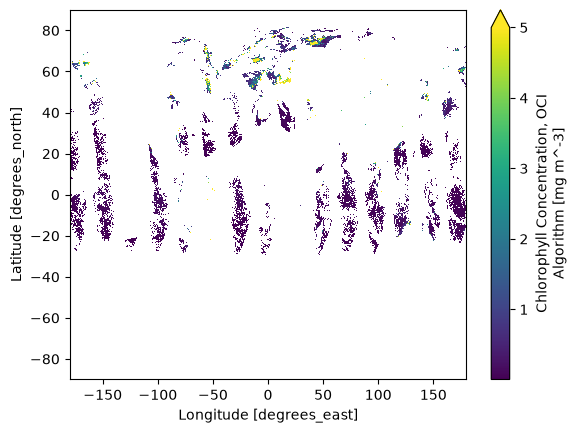

In [15]:
artist = dataset["chlor_a"].plot(vmax=5)

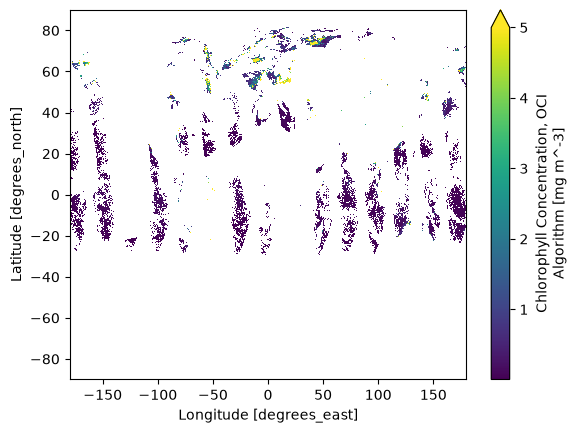

In [16]:
dataset = dataset.set_coords(("lon", "lat"))
plot = dataset["chlor_a"].plot(x="lon", y="lat", cmap="viridis", vmax=5)

## Normalizing data to use different variables together - kernel is dying when i run data_norm = data_norm.to_dataarray() cell

In [49]:
dataset_norm = dataset.astype(np.float64)
dataset_norm = (
    (dataset - dataset.min())
    / (dataset.max() - dataset.min())
)

In [ ]:
data_norm = dataset_norm.to_dataarray()

## Trying with old poster code

In [31]:
da_chla = dataset['chlor_a'].sel(lon = slice(150,180),
                               lat = slice(-55,-70))
da_chla

<xarray.DataArray 'chlor_a' (lat: 180, lon: 360)> Size: 259kB
[64800 values with dtype=float32]
Coordinates:
  * lat      (lat) float32 720B -55.04 -55.13 -55.21 ... -69.79 -69.88 -69.96
  * lon      (lon) float32 1kB 150.0 150.1 150.2 150.3 ... 179.8 179.9 180.0
Attributes:
    long_name:      Chlorophyll Concentration, OCI Algorithm
    units:          mg m^-3
    standard_name:  mass_concentration_of_chlorophyll_in_sea_water
    valid_min:      0.001
    valid_max:      100.0
    reference:      Hu, C., Feng, L., Lee, Z., Franz, B. A., Bailey, S. W., W...
    display_scale:  log
    display_min:    0.01
    display_max:    20.0

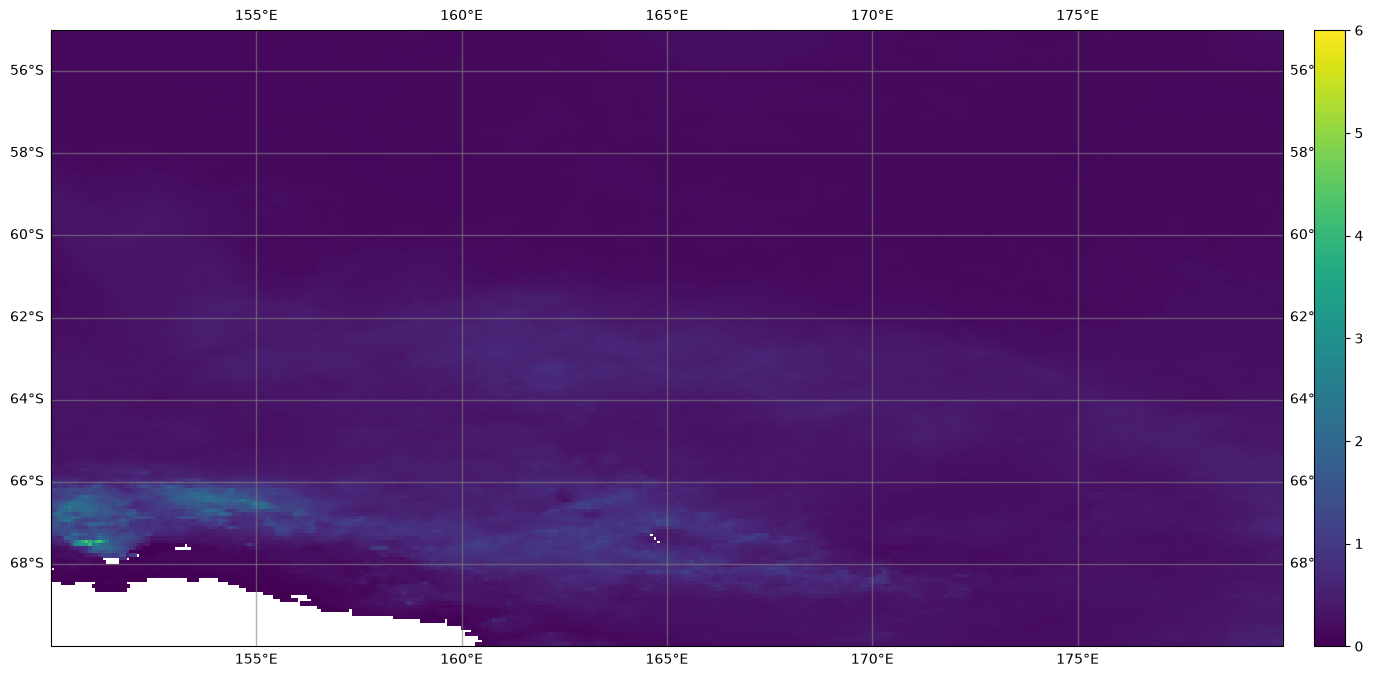

In [32]:
#assign projection type
crs0 = ccrs.PlateCarree()
#crs20 = ccrs.PlateCarree(central_longitude=80)

#create figure object
fig = plt.figure(figsize = (20,8))

#RECCAP regions panel
ax = fig.add_subplot(111, projection = crs0)

#Colormap specification
color = cmocean.cm.haline

# plot = da_chla.pcolor(cmap = color, transform = crs0,
#                       x = 'lon', y = 'lat', vmin = 0, vmax = 6, add_colorbar = True) 

plot = plt.pcolor(da_chla['lon'],da_chla['lat'],da_chla,
                 vmin = 0,vmax = 6) 

cbar = fig.colorbar(plot, fraction=0.02, pad=0.02)
# cbar.ax.tick_params(labelsize=tick_size)
# cbar.set_label('Chla', size=axis_size)

gl = ax.gridlines(crs=crs0, draw_labels=True, x_inline=False, y_inline=False,
                          linewidth=1, color='gray', alpha=0.6, linestyle='-')